In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
df = pd.read_csv("StudentsPerformance 1.csv")

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB
None


In [5]:
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [6]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [7]:
df["gender_num"] = df["gender"].map({"male": 0, "female": 1})

correlation = df.corr(numeric_only=True)
print(correlation)

               math score  reading score  writing score  gender_num
math score       1.000000       0.817580       0.802642   -0.167982
reading score    0.817580       1.000000       0.954598    0.244313
writing score    0.802642       0.954598       1.000000    0.301225
gender_num      -0.167982       0.244313       0.301225    1.000000


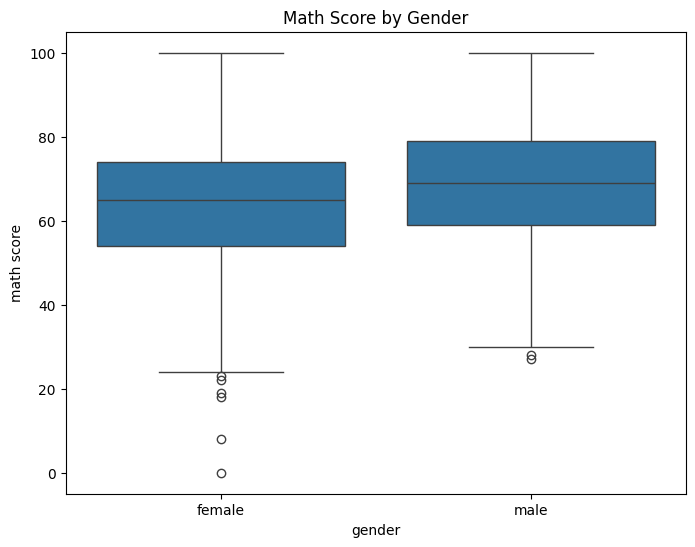

In [8]:
# Visualization 1: Math score by gender
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="gender", y="math score")
plt.title("Math Score by Gender")
plt.show()

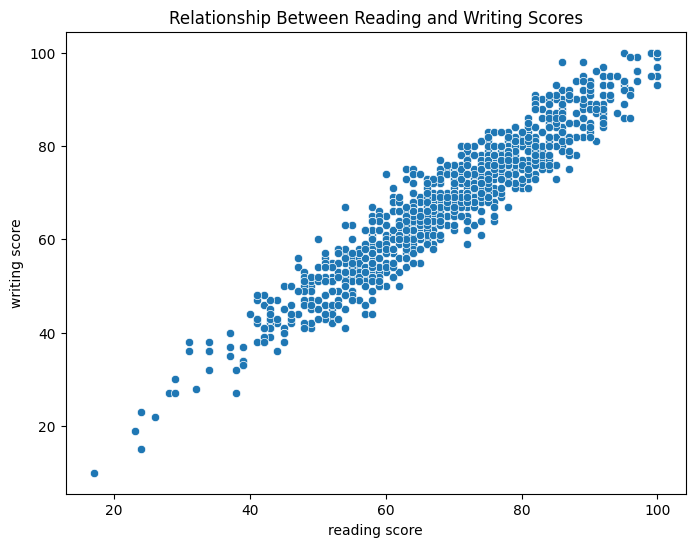

In [9]:
# Visualization 2: Reading and Writing (correlation)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="reading score",
    y="writing score"
)
plt.title("Relationship Between Reading and Writing Scores")
plt.show()

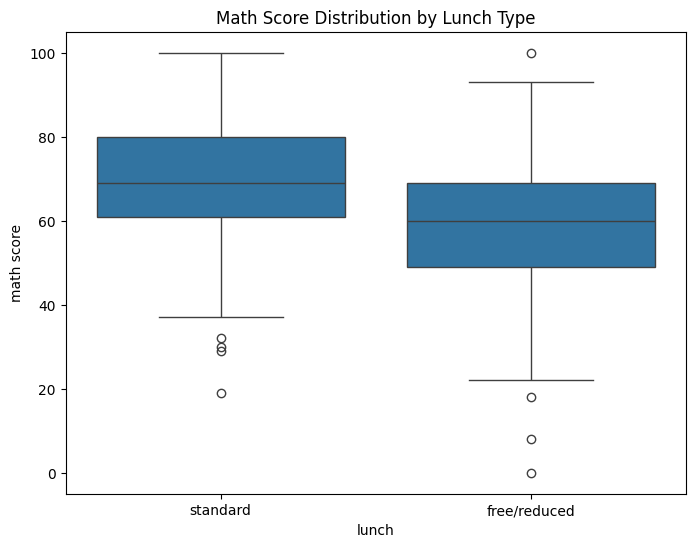

In [10]:
# Visualization 3
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="lunch", y="math score")
plt.title("Math Score Distribution by Lunch Type")
plt.show()

In [11]:
# 1. Average math score by gender
avg_math_gender = df.groupby("gender")["math score"].mean()
print("Average math score by gender:")
print(avg_math_gender)

Average math score by gender:
gender
female    63.633205
male      68.728216
Name: math score, dtype: float64


In [12]:
# 2. Correlation between reading and writing
print("Correlation between reading and writing:")
print(df["reading score"].corr(df["writing score"]))


Correlation between reading and writing:
0.9545980771462478


In [13]:
# 3. Do test preparation courses help?
prep_scores = df.groupby("test preparation course")[["math score", "reading score", "writing score"]].mean()
print("Test preparation course impact:")
print(prep_scores)

Test preparation course impact:
                         math score  reading score  writing score
test preparation course                                          
completed                 69.695531      73.893855      74.418994
none                      64.077882      66.534268      64.504673


In [14]:
# 4. Best parental education level
edu_scores = df.groupby("parental level of education")[["math score", "reading score", "writing score"]].mean()
print("Scores by parental education level:")
print(edu_scores)

Scores by parental education level:
                             math score  reading score  writing score
parental level of education                                          
associate's degree            67.882883      70.927928      69.896396
bachelor's degree             69.389831      73.000000      73.381356
high school                   62.137755      64.704082      62.448980
master's degree               69.745763      75.372881      75.677966
some college                  67.128319      69.460177      68.840708
some high school              63.497207      66.938547      64.888268


In [15]:
df["edu_degree"]=df["parental level of education"].map({'some college':0,'some high school':0,"high school":0,"bachelor's degree":2,"master's degree":3,"associate's degree":1})
cor = df.corr(numeric_only=True)
print(cor)

               math score  reading score  writing score  gender_num  \
math score       1.000000       0.817580       0.802642   -0.167982   
reading score    0.817580       1.000000       0.954598    0.244313   
writing score    0.802642       0.954598       1.000000    0.301225   
gender_num      -0.167982       0.244313       0.301225    1.000000   
edu_degree       0.132799       0.180871       0.219034    0.046516   

               edu_degree  
math score       0.132799  
reading score    0.180871  
writing score    0.219034  
gender_num       0.046516  
edu_degree       1.000000  


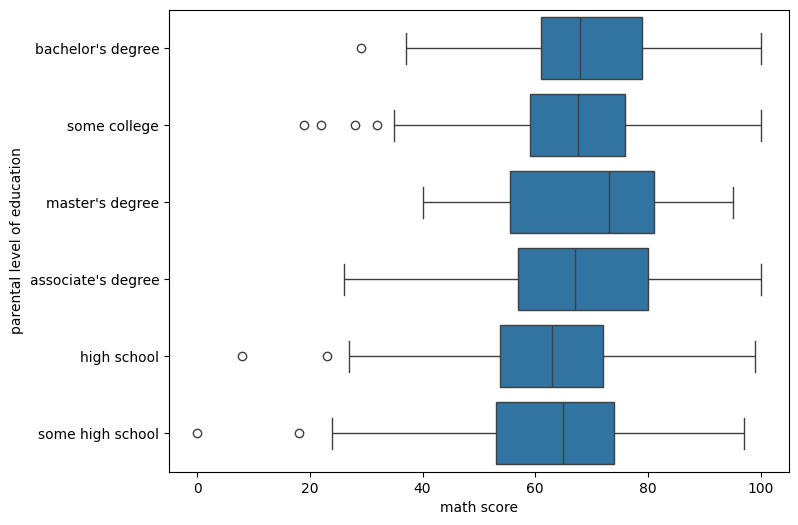

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data = df,
    x = "math score",
    y = "parental level of education"
)
plt.show()

In [17]:
# 5. Score distribution by lunch type
lunch_scores = df.groupby("lunch")[["math score", "reading score", "writing score"]].mean()
print("Scores by lunch type:")
print(lunch_scores)


Scores by lunch type:
              math score  reading score  writing score
lunch                                                 
free/reduced   58.921127      64.653521      63.022535
standard       70.034109      71.654264      70.823256


Additional tasks

In [18]:
#typical student's math score
print("average math score :", df['math score'].mean())
print("median math score:", df['math score'].median())

average math score : 66.089
median math score: 66.0


In [19]:
#variablility of test scores
print("Standard deviation of Math:", df['math score'].std())
print("Standard deviation of Reading:", df['reading score'].std())
print("Standard deviation of Writing:", df['writing score'].std())

Standard deviation of Math: 15.16308009600945
Standard deviation of Reading: 14.600191937252216
Standard deviation of Writing: 15.19565701086965


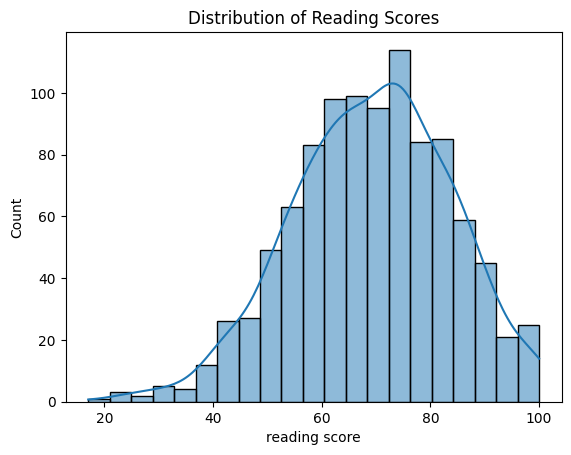

p-value : 0.0038537584035765824
Reading scores is not normal


In [20]:
#Are reading score's normally distributed?
plt.Figure(figsize=(6,4))
sns.histplot(df['reading score'],kde=True)
plt.title("Distribution of Reading Scores")
plt.show()

k,p = stats.normaltest(df['reading score'])
print("p-value :", p)
if p < 0.05:
    print("Reading scores is not normal")
else:
    print("Reading scores approximetly normal")

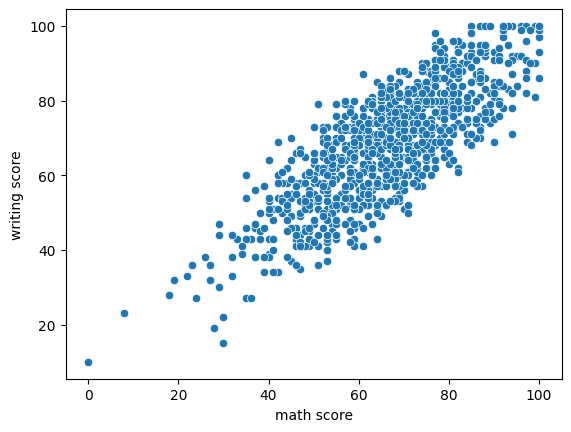

0.8026420459498085


In [21]:
#Do math and science scores relate?
# Math and Writing 
plt.Figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="math score",
    y="writing score"
)
plt.show()
c = df['math score'].corr(df['writing score'])
print(c)

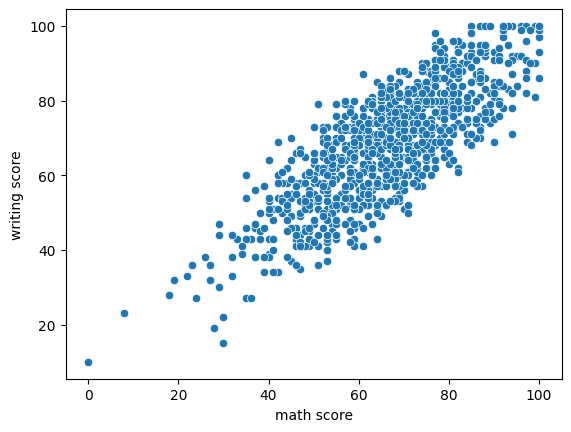

0.8175796636720544


In [22]:
#Do math and science scores relate?
# Math and Reading 
plt.Figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="math score",
    y="writing score"
)
plt.show()
c1 = df['math score'].corr(df['reading score'])
print(c1)


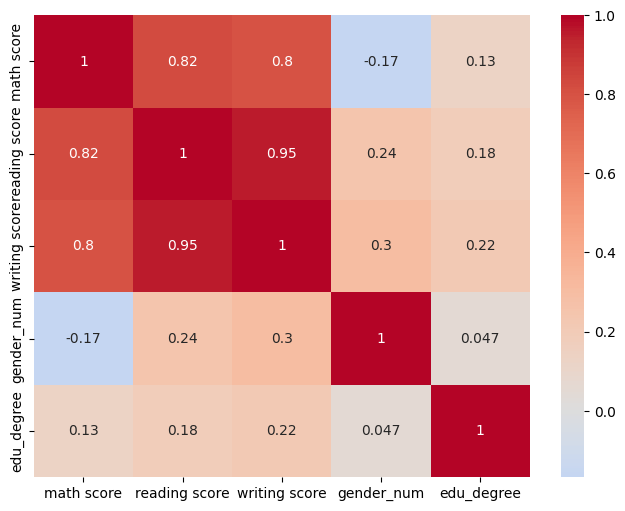

In [24]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()